<a href="https://colab.research.google.com/github/amitgold001/Analysis-Loan_Repaid-Model/blob/main/LoneData3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
import pandas as pd


In [135]:
data_info = pd.read_csv('/content/lending_club_info.csv',index_col='LoanStatNew')
data_info.loc['revol_util']['Description']

'Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.'

In [136]:
def feat_info(col_name):
  print(data_info.loc[col_name]['Description'])

In [137]:
feat_info('mort_acc')

Number of mortgage accounts.


**Loading the data and Exploring it**

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#
%matplotlib inline

In [139]:
df = pd.read_csv('/content/lending_club_loan_two.csv')

In [140]:
df

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396025,10000.0,60 months,10.99,217.38,B,B4,licensed bankere,2 years,RENT,40000.0,...,6.0,0.0,1990.0,34.3,23.0,w,INDIVIDUAL,0.0,0.0,"12951 Williams Crossing\nJohnnyville, DC 30723"
396026,21000.0,36 months,12.29,700.42,C,C1,Agent,5 years,MORTGAGE,110000.0,...,6.0,0.0,43263.0,95.7,8.0,f,INDIVIDUAL,1.0,0.0,"0114 Fowler Field Suite 028\nRachelborough, LA..."
396027,5000.0,36 months,9.99,161.32,B,B1,City Carrier,10+ years,RENT,56500.0,...,15.0,0.0,32704.0,66.9,23.0,f,INDIVIDUAL,0.0,0.0,"953 Matthew Points Suite 414\nReedfort, NY 70466"
396028,21000.0,60 months,15.31,503.02,C,C2,"Gracon Services, Inc",10+ years,MORTGAGE,64000.0,...,9.0,0.0,15704.0,53.8,20.0,f,INDIVIDUAL,5.0,0.0,"7843 Blake Freeway Apt. 229\nNew Michael, FL 2..."


In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

#1 Exploratory Data Analysis
 Overall Goal:Get an understanding for which veriable are imoportent, view summary statices, and visualize the data.

# New Section

<Axes: xlabel='loan_status', ylabel='count'>

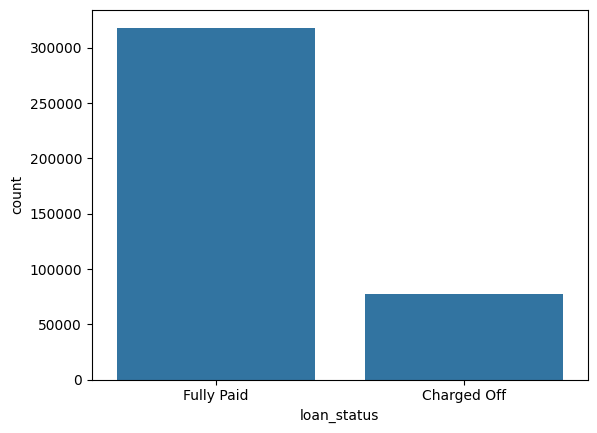

In [142]:
sns.countplot(x='loan_status',data=df)

Create a Histograme of the loan_amnt Column.

<ipython-input-143-84e1b31dd7ff>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_amnt'],kde=False,bins=40)


(0.0, 45000.0)

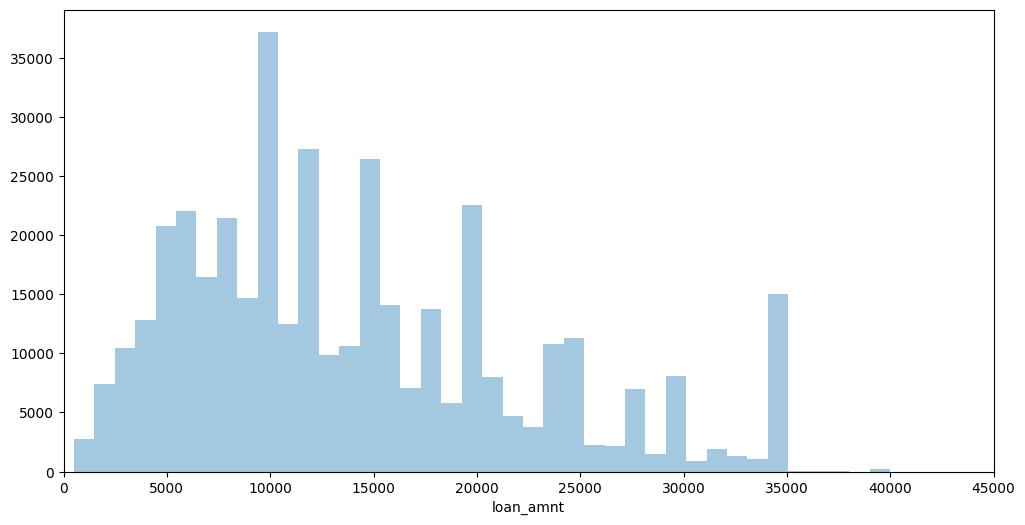

In [143]:
plt.figure(figsize=(12,6))
sns.distplot(df['loan_amnt'],kde=False,bins=40)
plt.xlim(0,45000)

 Task : Let's explore correlation between the condition feature variable. Calculate the correletion between all continious numeric variable using.coor() methorde

In [144]:

# Calculating correlation only for numeric features
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                      loan_amnt  int_rate  installment  annual_inc       dti  \
loan_amnt              1.000000  0.168921     0.953929    0.336887  0.016636   
int_rate               0.168921  1.000000     0.162758   -0.056771  0.079038   
installment            0.953929  0.162758     1.000000    0.330381  0.015786   
annual_inc             0.336887 -0.056771     0.330381    1.000000 -0.081685   
dti                    0.016636  0.079038     0.015786   -0.081685  1.000000   
open_acc               0.198556  0.011649     0.188973    0.136150  0.136181   
pub_rec               -0.077779  0.060986    -0.067892   -0.013720 -0.017639   
revol_bal              0.328320 -0.011280     0.316455    0.299773  0.063571   
revol_util             0.099911  0.293659     0.123915    0.027871  0.088375   
total_acc              0.223886 -0.036404     0.202430    0.193023  0.102128   
mort_acc               0.222315 -0.082583     0.193694    0.236320 -0.025439   
pub_rec_bankruptcies  -0.106539  0.05745

(10.0, 0.0)

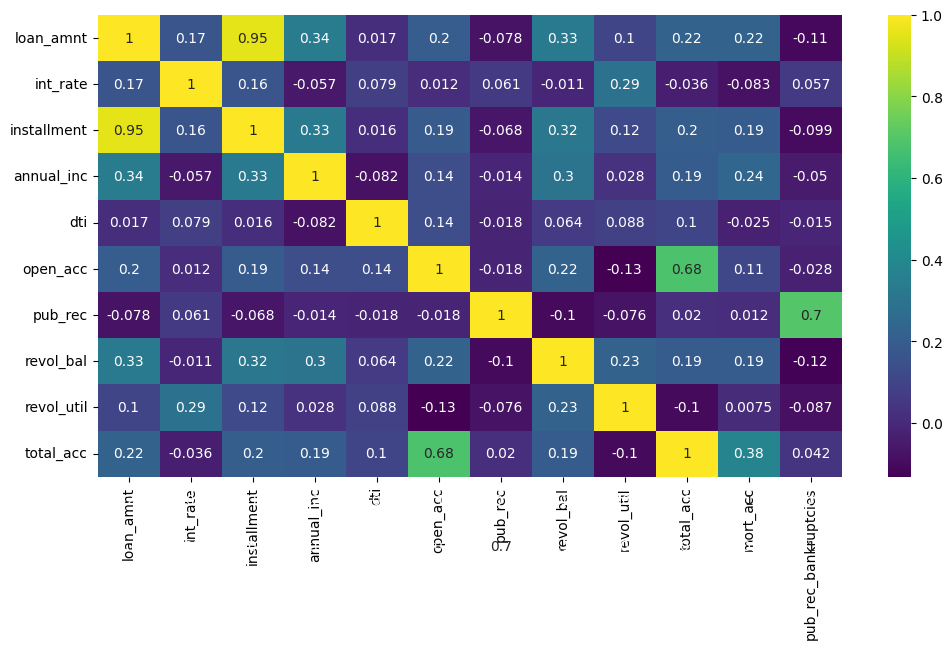

In [145]:
plt.figure(figsize=(12,6))
sns.heatmap(correlation_matrix,annot=True,cmap='viridis')
plt.ylim(10,0)

In [146]:
feat_info('installment')

The monthly payment owed by the borrower if the loan originates.


In [147]:
feat_info('loan_amnt')

The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.


<Axes: xlabel='installment', ylabel='loan_amnt'>

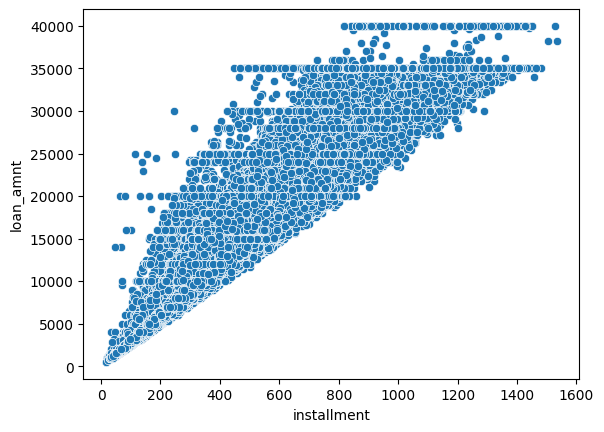

In [148]:
sns.scatterplot(x='installment',y='loan_amnt',data=df,)

Create a Boxplot showing the relationship between the loan_status and the Loan Amount.

<ipython-input-149-771cd73d25d4>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status',y='loan_amnt', palette='Set3',data=df)


<Axes: xlabel='loan_status', ylabel='loan_amnt'>

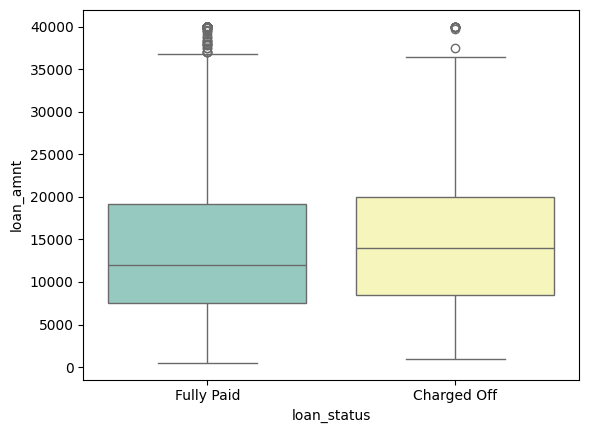

In [149]:
sns.boxplot(x='loan_status',y='loan_amnt', palette='Set3',data=df)

Calculate the summery statistic for the loan amount, grouped by the loan_status.

In [150]:
df.groupby('loan_status')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Charged Off,77673.0,15126.300967,8505.090557,1000.0,8525.0,14000.0,20000.0,40000.0
Fully Paid,318357.0,13866.878771,8302.319699,500.0,7500.0,12000.0,19225.0,40000.0


Let's Explore the Grade and SubGrade columns that LendingClub attribute to the loans. What are the unique possible grades and subgrades?

In [151]:
#sorted(df['grade'].unique())
sorted(df['grade'].astype(str).unique())

['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [152]:
sorted(df['sub_grade'].astype(str).unique())

['A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'B1',
 'B2',
 'B3',
 'B4',
 'B5',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'E1',
 'E2',
 'E3',
 'E4',
 'E5',
 'F1',
 'F2',
 'F3',
 'F4',
 'F5',
 'G1',
 'G2',
 'G3',
 'G4',
 'G5']

Create a countplotper grade.Set the hue to the loan_status label.

<Axes: xlabel='grade', ylabel='count'>

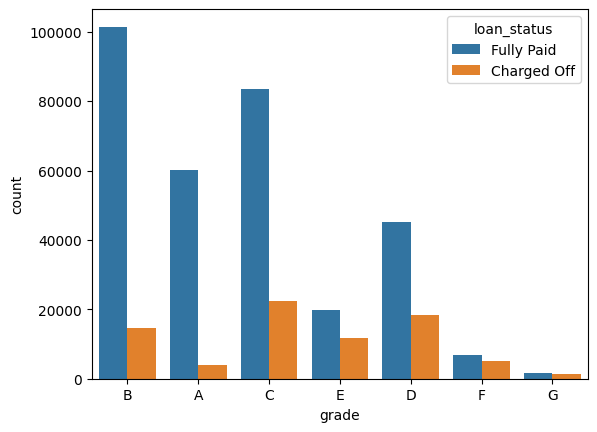

In [153]:
sns.countplot(x='grade',data=df,hue='loan_status')

Display a count plot per subgrade. You may need to resize for this plot and recode the x axis. Feel free to edite the color palette. Explore both all loans made per subgrade as well being Sebgrade as well being sepredte base on the loan_status

<ipython-input-154-095cd7a77f00>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sub_grade',data=df,order=subgrade_order,palette='coolwarm')


<Axes: xlabel='sub_grade', ylabel='count'>

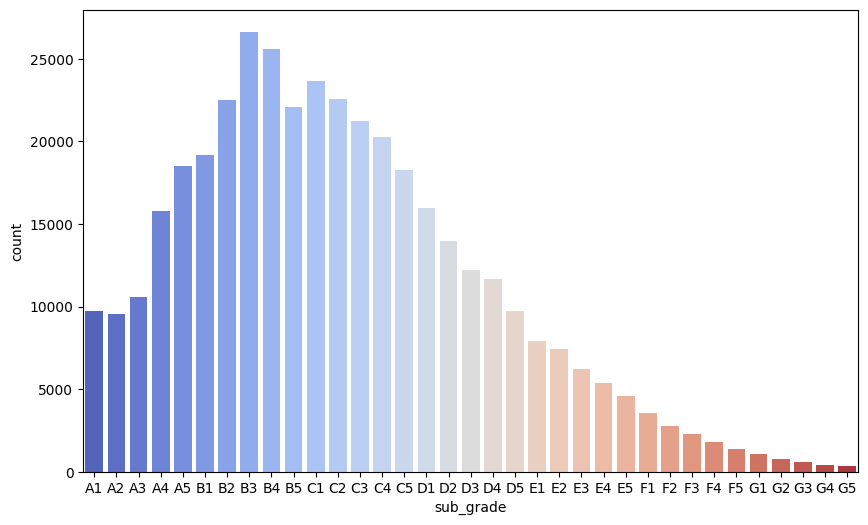

In [154]:
plt.figure(figsize=(10,6))
subgrade_order = sorted(df['sub_grade'].astype(str).unique())
sns.countplot(x='sub_grade',data=df,order=subgrade_order,palette='coolwarm')

<Axes: xlabel='sub_grade', ylabel='count'>

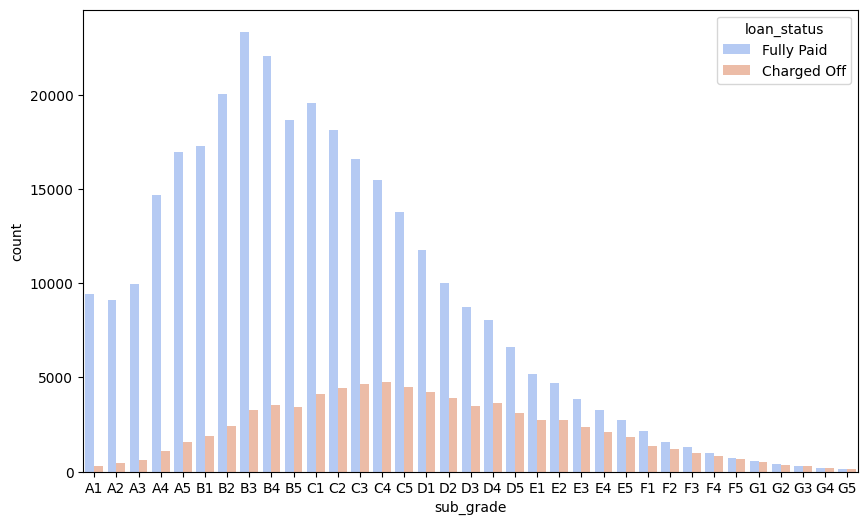

In [155]:
plt.figure(figsize=(10,6))
subgrade_order = sorted(df['sub_grade'].astype(str).unique())
sns.countplot(x='sub_grade',data=df,order=subgrade_order,palette='coolwarm',hue='loan_status')

Its looks like F and G subgrades don't get paid back the often. Isolate those and recrate the countplot just for those subgrades.

<Axes: xlabel='sub_grade', ylabel='count'>

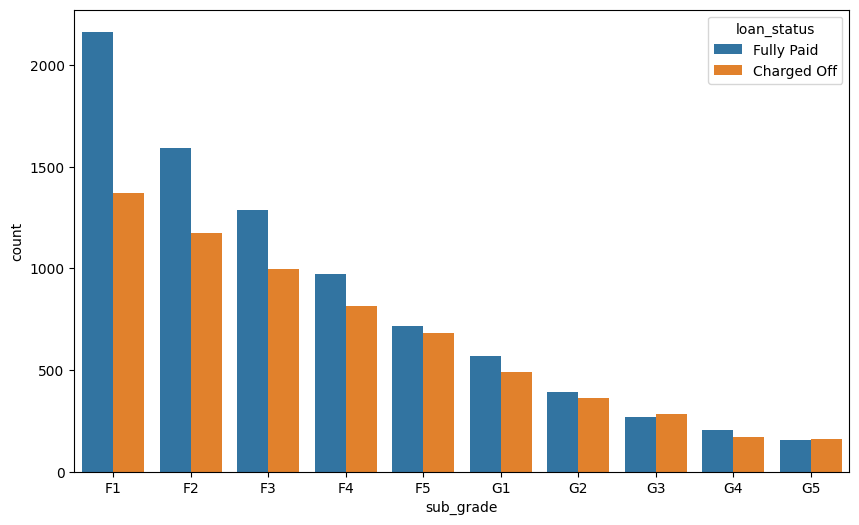

In [156]:
f_and_g = df[(df['grade']=='G') | (df['grade']=='F')]
plt.figure(figsize=(10,6))
subgrade_order = sorted(f_and_g['sub_grade'].astype(str).unique())
sns.countplot(x='sub_grade',data=f_and_g,order=subgrade_order,hue='loan_status')

Create a new column called 'loan_repaid' which will coutain a 1 if the loan status was 'Fully Paid" and a 0 if it was"Changed Off"

In [157]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

In [158]:
df['loan_repaid'] = df['loan_status'].map({'Fully Paid':1,'Changed Off':0})

In [159]:
df[['loan_repaid','loan_status']]

,loan_repaid,loan_status
0,1.0,Fully Paid
1,1.0,Fully Paid
2,1.0,Fully Paid
3,1.0,Fully Paid
4,NaN,Charged Off
...,...,...
396025,1.0,Fully Paid
396026,1.0,Fully Paid
396027,1.0,Fully Paid
396028,1.0,Fully Paid


Create a bar plot showing the correlation of the numeric features to the new loan_repaid colimns.

/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Axes: >

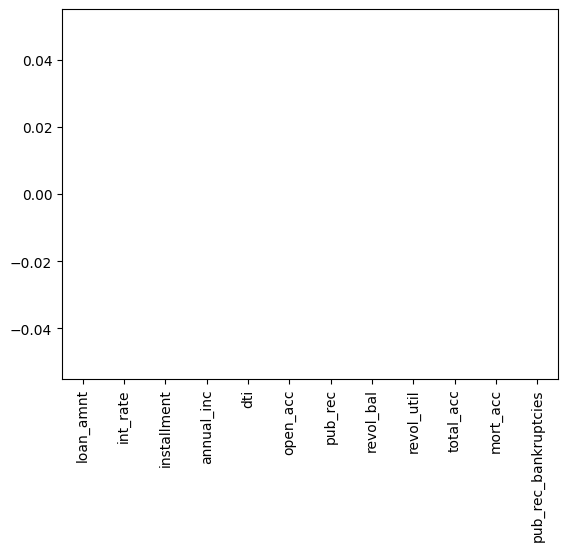

In [160]:
#df.corr['loan_repaid'].sort_values('loan_repaid').plot(kind='bar')
loan_repaid_corr = numeric_df.corrwith(df['loan_repaid']).sort_values()
loan_repaid_corr.plot(kind='bar')

# 2: Data PreProcessing
section Goals: Remove or fill any missing data. Remove unnecessay or  repetitive features. Convert Categorical string  features to dummy variables

In [161]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,loan_repaid
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690",1.0
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113",1.0
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113",1.0
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813",1.0
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650",NaN


# Missing Data

In [162]:
len(df)

396030

Create a Series that displays the total count of missing values per column

In [163]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


Convert this Series to be in term of percentage of the total DatFrame

In [164]:
100* df.isnull().sum()/len(df)

,0
loan_amnt,0.000000
term,0.000000
int_rate,0.000000
installment,0.000000
grade,0.000000
sub_grade,0.000000
emp_title,5.789208
emp_length,4.621115
home_ownership,0.000000
annual_inc,0.000000


Let's examine emp_title and emp_length to see whether it will be okey to drop them . print out their feature information using the feat_information using the feat_info() function from the top of this notebook

In [165]:
feat_info('emp_title')
print('\n')
feat_info('emp_length')

The job title supplied by the Borrower when applying for the loan.*


Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 


How many unique employment job titles are there

In [166]:
df['emp_title'].nunique()

173105

In [167]:
df['emp_title'].value_counts()

,count
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830
...,...
Postman,1
"McCarthy & Holthus, LLC",1
jp flooring,1


Realistically there are too many unique job to try to convert this to a dummy variable featue. Let's remove that emp_title column

In [168]:
df = df.drop('emp_title',axis=1)

Create a count plot of the emp_length feature column. Cahllenge: Sort the order of the values.

In [169]:
sorted(df['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

<Axes: xlabel='emp_length', ylabel='count'>

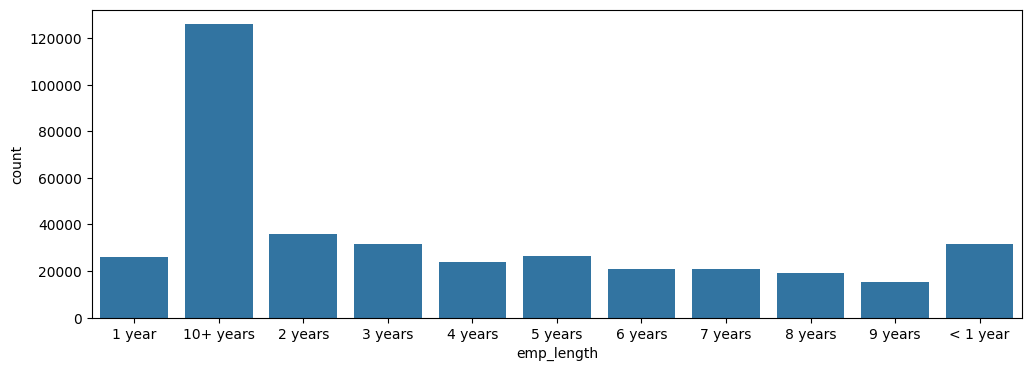

In [170]:
plt.figure(figsize=(12,4))
emp_length_order = sorted(df['emp_length'].dropna().unique()) # Define emp_length_order here
sns.countplot(x='emp_length',data=df,order=emp_length_order)

Plot out the countplot with a hue separating Fully Paid Vs Charged off

<Figure size 1800x400 with 0 Axes>

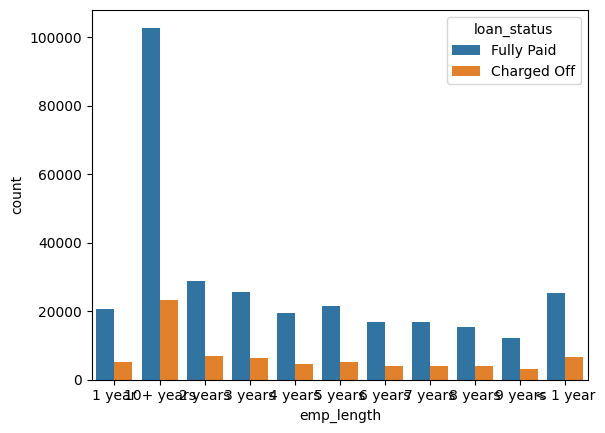

<Figure size 1800x400 with 0 Axes>

In [171]:
sns.countplot(x='emp_length',data=df,order=emp_length_order,hue='loan_status')
plt.figure(figsize=(18,4))

This still doesn't really inform us if there is a strong realationship between length and being charged off, what off, what we want is the percentage of charge offs per category. Eeentially Information us what percent of people per employment category didn't pay bavk therir loan. There are multitude of ways to create this Series. Once you've created it, see if visualize it with a bar plot.**bold text** . This may be trick, refe to solutions if you get stuck on creating this Series.

In [172]:
emp_co = df[df['loan_status']== 'Charged Off'].groupby('emp_length').count()['loan_status']

In [173]:
emp_fp = df[df['loan_status'] =='Fully Paid'].groupby('emp_length').count()['loan_status']

In [174]:
emp_len = emp_co/emp_fp

In [175]:
emp_len

,loan_status
emp_length,
1 year,0.248649
10+ years,0.225770
2 years,0.239560
3 years,0.242593
4 years,0.238213
5 years,0.237911
6 years,0.233341
7 years,0.241887
8 years,0.249625


<Axes: xlabel='emp_length'>

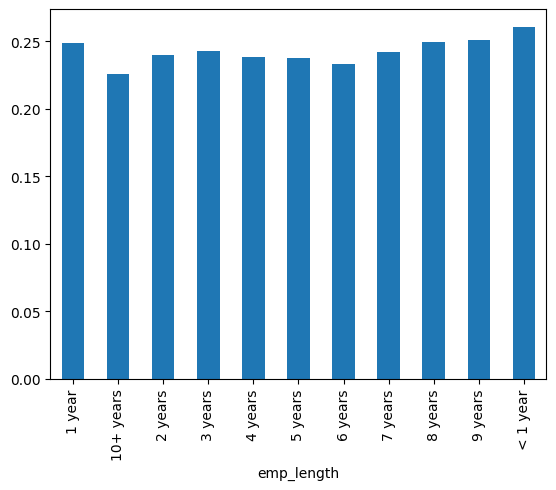

In [176]:
emp_len.plot(kind='bar')

Change off rating are extremely similar across all employment lengths. Go ahead and drop the emp_length column.

In [177]:
df = df.drop('emp_length',axis=1)

Revisit the DataFrame to see what feature columns still have missing data.

In [178]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


Review the title Column vs the purpose columns . Is this repeated information.

In [179]:
df['purpose'].head(10)

,purpose
0,vacation
1,debt_consolidation
2,credit_card
3,credit_card
4,credit_card
5,debt_consolidation
6,home_improvement
7,credit_card
8,debt_consolidation
9,debt_consolidation


In [180]:
df['title'].head(10)

,title
0,Vacation
1,Debt consolidation
2,Credit card refinancing
3,Credit card refinancing
4,Credit Card Refinance
5,Debt consolidation
6,Home improvement
7,No More Credit Cards
8,Debt consolidation
9,Debt Consolidation


The titel columns is simply a string subcategery/description of the purpose columns. Go ahead and drop the title columums.

In [181]:
df= df.drop('title',axis=1)

Find out what the most_add feature represents

In [182]:
feat_info('mort_acc')

Number of mortgage accounts.


In [183]:
# values count of the mort_acc columns
df['mort_acc'].value_counts()

,count
mort_acc,
0.0,139777
1.0,60416
2.0,49948
3.0,38049
4.0,27887
5.0,18194
6.0,11069
7.0,6052
8.0,3121


 There are many ways we could deal with this missing data. We could attempt to build a simple model to fill it in, such as a linear model, we could just fill it in based on the mean of the other columns, or you could even bin the columns into categories and then set NaN as its own category. There is no 100% correct approach! Let's review the other columsn to see which most highly correlates to mort_acc

In [184]:
# Now calculate the correlation, but only for numeric features
numeric_df = df.select_dtypes(include=np.number)  # Select only numeric columns
print('Correlation with mort_acc column')
correlation_matrix = numeric_df.corr()
print(correlation_matrix['mort_acc'].sort_values())

Correlation with mort_acc column
int_rate               -0.082583
dti                    -0.025439
revol_util              0.007514
pub_rec                 0.011552
pub_rec_bankruptcies    0.027239
open_acc                0.109205
installment             0.193694
revol_bal               0.194925
loan_amnt               0.222315
annual_inc              0.236320
total_acc               0.381072
mort_acc                1.000000
loan_repaid                  NaN
Name: mort_acc, dtype: float64


Look like the total_acc feature correlates with the mort_acc, This makes sense! Let's try this fillna() approach. We will group the dataframe by the total_acc and calculate the mean values fro the most_acc per total entry.To get the result below:

In [185]:
print("Mean of mort_acc column per total_acc")
# Select only numeric columns, including 'mort_acc' and 'total_acc'
numeric_df = df[['mort_acc', 'total_acc']].apply(pd.to_numeric, errors='coerce')

# Group by 'total_acc' and calculate the mean of 'mort_acc' for each group
mean_mort_acc_per_total_acc = numeric_df.groupby('total_acc')['mort_acc'].mean()

print(mean_mort_acc_per_total_acc)

Mean of mort_acc column per total_acc
total_acc
2.0      0.000000
3.0      0.052023
4.0      0.066743
5.0      0.103289
6.0      0.151293
           ...   
124.0    1.000000
129.0    1.000000
135.0    3.000000
150.0    2.000000
151.0    0.000000
Name: mort_acc, Length: 118, dtype: float64


 Let's fill in the missing mort_acc values based on their total_acc value. If the mort_acc is missing, then we will fill in that missing value with the mean value corresponding to its total_acc value from the Series we created above. This involves using an .apply() method with two columns. Check out the link below for more info, or review the solution

In [186]:
#total_acc_avg = df.groupby('total_acc').mean()['mort_acc']
total_acc_avg = df.groupby('total_acc')['mort_acc'].transform(lambda x: x.fillna(x.mean()))

In [187]:
total_acc_avg[2.0]

0.0

In [188]:
def fill_mort_acc(total_acc,mort_acc):
  '''Accepts the toal_acc and moral_acc values for the row.
  check if the mort_acc is NaN, if so, it retuen the avg values
  for the corresponding total_acc values for the row.
  Total_acc_avg here should be a Series or directely conntinig the mapping
  of the groupby averages of mort_acc total_acc values '''

  if np.isnan(mort_acc):
    return total_acc_avg[total_acc]
  else:
    return mort_acc

In [189]:
df['mort_acc']= df.apply(lambda x: fill_mort_acc(x['total_acc'],x['mort_acc']), axis=1)

In [73]:
#total_acc_avg = df.groupby('total_acc').mean()['mort_acc']
total_acc_avg = df.groupby('total_acc')['mort_acc'].transform(lambda x: x.fillna(x.mean()))

# Add this check in the fill_mort_acc function
def fill_mort_acc(total_acc,mort_acc):
    '''Accepts the toal_acc and moral_acc values for the row.
    check if the mort_acc is NaN, if so, it retuen the avg values
    for the corresponding total_acc values for the row.
    Total_acc_avg here should be a Series or directely conntinig the mapping
    of the groupby averages of mort_acc total_acc values '''

    # Check if total_acc is NaN. If so, return NaN.
    if pd.isnull(total_acc):
        return np.nan

    if np.isnan(mort_acc):
        return total_acc_avg[total_acc]
    else:
        return mort_acc

df['mort_acc'] = df.apply(lambda x: fill_mort_acc(x['total_acc'], x['mort_acc']), axis=1)

In [190]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


revol_util and the pub_rec_bankrupticies have missing data points, But they account for than 0.5% of the toal data. Go ahede and remove the row that and missing those values in those columns with dropna()

In [191]:
df = df.dropna()

In [192]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
home_ownership,0
annual_inc,0
verification_status,0
issue_d,0


# Categorical Variables and Dummy Variable
we're done working with the missing data! Now we just need to deal with values due to category columns.
Let's all the coluns that are currently non-nomeric.

In [193]:
df.select_dtypes(['object']).columns

Index(['term', 'grade', 'sub_grade', 'home_ownership', 'verification_status',
       'issue_d', 'loan_status', 'purpose', 'earliest_cr_line',
       'initial_list_status', 'application_type', 'address'],
      dtype='object')

Let's now go through all the string features to see what should do with them

Term featue
 Convert the term feature into eiher a 36 or 60 integer numeric data type using .appy() or map()

In [194]:
df['term'].value_counts()

,count
term,
36 months,253740
60 months,63956


In [195]:
# or just use .map()
df['term'] = df['term'].apply(lambda term: int(term[:3]))

In [196]:
if df['term'].dtype == 'object': #If data type is object (string)
        df['term'] = df['term'].apply(lambda term: int(term.split()[0])) # Apply the original transformation
    # If not an object, it means the 'term' column is already an integer so we don't modify it

**Grade Feature**



We already Know grade is part of sub_grade, so jsut drop the grade ferure.

In [197]:
df =df.drop('grade',axis=1)

Convert the subgrade into dummy veriables. The constenate these new columns to the original dataframe. Remember to drop the original subgrade columns and to add drop_first=True to your get_dummies call.

In [198]:
subgrade_dummies = pd.get_dummies(df['sub_grade'],drop_first=True)

In [199]:
df = pd.concat([df.drop('sub_grade',axis=1),subgrade_dummies],axis=1)

In [200]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'dti', 'earliest_cr_line', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'address',
       'loan_repaid', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5',
       'C1', 'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2',
       'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4',
       'G5'],
      dtype='object')

In [201]:
df.select_dtypes(['object']).columns

Index(['home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

**Verification_status, Application_type, initial_list_status,Purpose**



Converte these['Verification_status', application_type', list_status,purpose', into dummy veriable and concate them with the original dataframe . Remember to set. drop_first= True and to drop the original columns

In [202]:
dummies = pd.get_dummies(df[['verification_status','application_type','initial_list_status','purpose']],drop_first=True)
# Use df.drop instead of pd.drop to drop columns from the DataFrame
df = df.drop(['verification_status','application_type','initial_list_status','purpose'],axis=1)
df  = pd.concat([df,dummies],axis=1)

Home_ownership
Reviow the values_count for the home_ownership column.

In [203]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,164443
RENT,123260
OWN,29874
OTHER,94
NONE,22
ANY,3


Convert these to dummey veriables, but replace NONE and ANY with other, so that we end up with just 4 categories, MORTGAGE, RENT, OWN,OTHER, OTHER. Then concatenate them with the original dataFrame. Remember to set drop_first=True and to drop the orinal columns

In [204]:
df['home_ownership']=df['home_ownership'].replace(['NONE','ANY'],'OTHER')
dummies = pd.get_dummies(df['home_ownership'],drop_first=True)
df = df.drop('home_ownership',axis=1)
df = pd.concat([df,dummies],axis=1)

**Addrerss**


Now make this zip_code columns into dummeys variable using pandas. Concatenate the result and drop original zip_corde columns along woth dropoing the adderess column.

In [205]:
df['zip_code']= df['address'].apply(lambda address:address[-5:]) # Corrected the typo: address instead of adderess

In [206]:
dummies = pd.get_dummies(df['zip_code'],drop_first=True)
df = df.drop(['zip_code','address'],axis=1)
df = pd.concat([df,dummies],axis=1)

**issue_d**

This would be data leakage, we wouldn't know beforehade whether or not a loan be issued when using our model, so in theory we would't have an issue_date, drop this featue.

In [207]:
df['earliest_cr_line_year'] = df['earliest_cr_line'].apply(lambda date: int(date[-4:]))
df = df.drop('earliest_cr_line',axis=1)

In [208]:
df.select_dtypes(['object']).columns

Index(['issue_d', 'loan_status'], dtype='object')

**Train Test Split**


Import train_test_split from sklearn.

In [209]:
from sklearn.model_selection import train_test_split

Drop the load_status columns we created earlier, since its a duplicate of the loan_repaid columns. We'll use the loan_repaid columns since its already in 0 and 1s.

In [210]:
df = df.drop('loan_status',axis=1)

Set X and Y variable to the .values of the features and label.

In [211]:
X = df.drop('loan_repaid',axis=1).values
y =df['loan_repaid'].values

**OPTIONAL **


USE. sample for Training Time
USE.sample() to grab a sample of the 490K+ entity to save time on trainig. Highly Recommended for lower RAM computers or if you are not using GPU.

In [212]:
print(len(df))

317696


Perform a train/test split with test_size=0.2 and a random_state of 101.

In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [214]:
# Assuming the column is still in the DataFrame and of string data type
if 'earliest_cr_line' in df.columns and df['earliest_cr_line'].dtype == 'object':
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
  df['earliest_cr_line'] = df['earliest_cr_line'].apply(lambda date: int(date.strftime('%Y')))
else:
  print("Column 'earliest_cr_line' not found or already processed.")

Column 'earliest_cr_line' not found or already processed.


# Normalizing the DATA

Use a MinMaxScaler to normaliza the feature data X_train and X_test. Recall we Don't want data leaked from the test se only fit on the X_train data.

In [215]:
from sklearn.preprocessing import MinMaxScaler

In [216]:
scaler = MinMaxScaler()

In [217]:
# Assuming the column is still in the DataFrame and of string data type
if 'earliest_cr_line' in df.columns and df['earliest_cr_line'].dtype == 'object':
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
  df['earliest_cr_line'] = df['earliest_cr_line'].apply(lambda date: int(date.strftime('%Y')))
else:
  print("Column 'earliest_cr_line' not found or already processed.")

# ... (rest of your code) ...

# After processing 'earliest_cr_line', recreate X and y:
# Check if 'loan_repaid' is in the DataFrame columns
if 'loan_repaid' in df.columns:
  X = df.drop('loan_repaid',axis=1).values
  y =df['loan_repaid'].values
else:
  print("Column 'loan_repaid' not found in the DataFrame.")
  # Handle the missing column appropriately, for example:
  # 1. Investigate where the column was dropped/renamed and restore it
  # 2. Create a new 'loan_repaid' column if it was intentionally removed
  # 3. Exit the code execution if the column is essential


# ... (continue with train_test_split and scaling) ...

Column 'earliest_cr_line' not found or already processed.


# CREATING THE MODEL


Run the cell below to import the necessary Keran Function .

In [218]:
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout
from tensorflow.keras.optimizers import Adam

In [219]:
model = Sequential()
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(0.5))

In [220]:
model = Sequential()
#

#input layer

model.add(Dense(units=78,activation='relu'))
model.add(Dropout(0.2))

#Hidden layers

model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(0.3))

#output layer

In [221]:
model = Sequential()
#

#input layer

model.add(Dense(units=78,activation='relu'))
model.add(Dropout(0.2))

#Hidden layers

model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=64,activation='relu'))
model.add(Dropout(0.3))

#output layer
model.add(Dense(units=1,activation='sigmoid')) # Output layer for binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam') # Example using binary_crossentropy and adam optimizer

# saving the model

In [222]:
from tensorflow.keras.models import load_model

In [223]:
model.save('loan_repaid_model.h5')

# Evaluaating MOdel Perfrmane


Plot out the validation loss versus the training loss
